# M3 — BEV Grid Conversion & CNN Architecture

Goal for this notebook: the first two `ROADMAP.md` M3 sub-goals only — implement the BEV
converter and initialise the CNN architecture. Training (loss, optimizer, epochs, val-loss
monitoring, comparison against the M2 baseline) is a deliberately separate later step; every
model output shown here comes from a freshly-initialised, untrained network.

Four design decisions were made before writing any code, driven by measuring the actual
dataset rather than assuming a standard recipe (e.g. ResNet-18 on a fixed-size crop) would
fit this data:

1. **Grid sizing** — variable-size grid per tile (fixed cell size, native extent) with
   global adaptive pooling in the CNN, instead of a fixed physical window.
2. **Channels** — 3 per cell (density, mean height, mean intensity), not occupancy alone.
3. **Framework** — PyTorch.
4. **Architecture** — a small purpose-built CNN (~100K params), not ResNet-18 (~11M params).

Section 1 shows the measurements behind decision 1; section 2 covers the architecture
(decisions 3-4) and decision 2 is covered in `src/bev.py`'s docstring/section 1 here.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data import CLASSES, get_splits, load_points
from src.bev import points_to_bev, RESOLUTION_M, CHANNEL_NAMES
from src.cnn import LaneCNN

CLASS_COLORS = {
    "2lanes":      "#2a78d6",
    "3lanes":      "#eb6834",
    "split4lanes": "#1baf7a",
    "split6lanes": "#eda100",
    "transition":  "#e87ba4",
    "crossing":    "#008300",
}

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 140, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
})

splits = get_splits()
train = splits["train"]

## 1. BEV grid conversion

`src/bev.py` bins each tile's points into `resolution`-metre cells over the local x/y plane
(default 0.3m, matching the dataset's own `grid_index_0.3m` feature). Every cell gets 3
channels: `log1p(point count)`, mean height (`local_z`), and mean intensity normalised by
the sensor's fixed 16-bit range (65535) -- a constant, not fit on any split, so it can't leak
train/val/test information.

**Why not a fixed-size grid?** Measuring tile extent on the train split first:

In [2]:
x_ranges, y_ranges = [], []
for rel_path, _cls, _label in train:
    pts = load_points(rel_path)
    x_ranges.append(pts[:, 0].max() - pts[:, 0].min())
    y_ranges.append(pts[:, 1].max() - pts[:, 1].min())
x_ranges, y_ranges = np.array(x_ranges), np.array(y_ranges)

extent_stats = pd.DataFrame({
    "x_range [m]": [x_ranges.min(), np.median(x_ranges), x_ranges.max()],
    "y_range [m]": [y_ranges.min(), np.median(y_ranges), y_ranges.max()],
}, index=["min", "median", "max"])
extent_stats

,x_range [m],y_range [m]
min,4.624315,2.086620
median,20.601656,9.996490
max,29.999693,24.903748


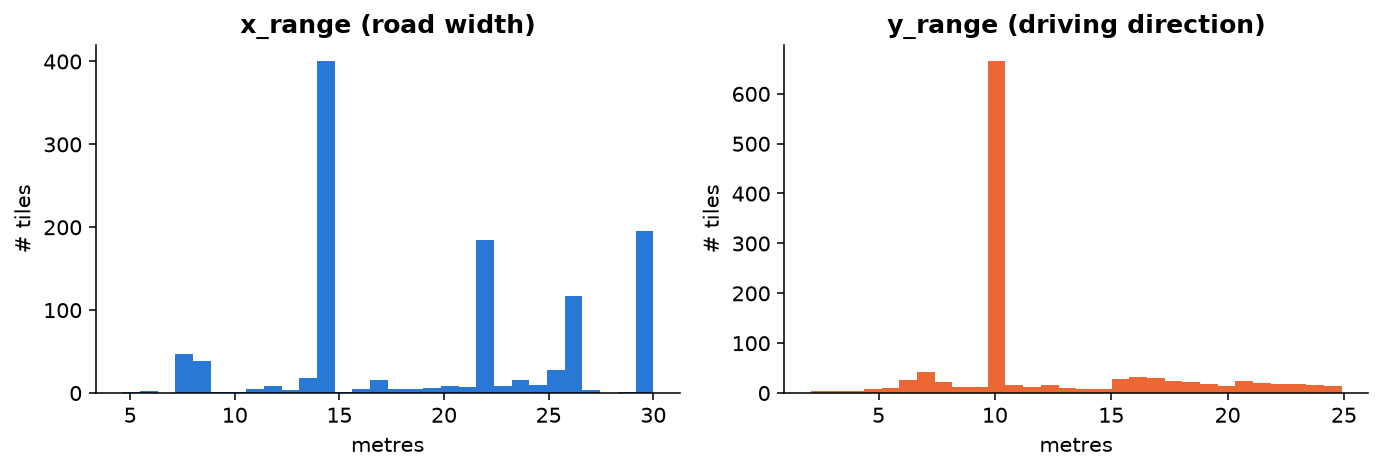

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(x_ranges, bins=30, color="#2a78d6")
axes[0].set_title("x_range (road width)"); axes[0].set_xlabel("metres")
axes[1].hist(y_ranges, bins=30, color="#eb6834")
axes[1].set_title("y_range (driving direction)"); axes[1].set_xlabel("metres")
for ax in axes:
    ax.set_ylabel("# tiles")
plt.tight_layout()
plt.show()

A single fixed window would have to cover the max in both axes (~30m x ~25m) to avoid
cropping any tile, but the median tile is only ~21m x ~10m -- most of that fixed window would
be empty padding for a typical tile. A variable-size grid (fixed cell size, extent read off
each tile) avoids that trade-off entirely; the CNN's adaptive pooling head (section 2) is
what makes a variable grid size usable as network input.

tile: dataset/2lanes/Tile620.npy
points: 5881, grid shape (C, H, W): (3, 74, 47)
H * resolution = 22.20m vs actual y_range = 22.13m
W * resolution = 14.10m vs actual x_range = 14.00m


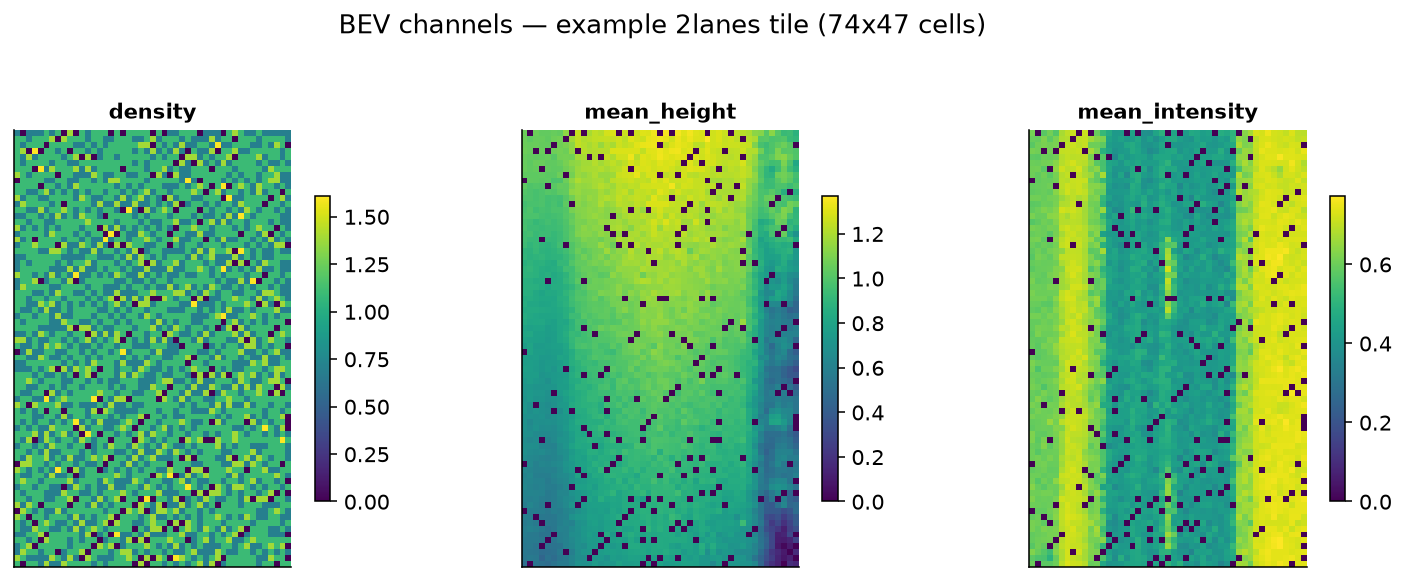

In [4]:
example_path = "dataset/2lanes/Tile620.npy"  # a mid-width, long 2lanes tile -- picked for a clear view of lane-marking structure
example_pts = load_points(example_path)
grid = points_to_bev(example_pts)
print(f"tile: {example_path}")
print(f"points: {example_pts.shape[0]}, grid shape (C, H, W): {grid.shape}")
print(f"H * resolution = {grid.shape[1] * RESOLUTION_M:.2f}m vs actual y_range = "
      f"{example_pts[:,1].max() - example_pts[:,1].min():.2f}m")
print(f"W * resolution = {grid.shape[2] * RESOLUTION_M:.2f}m vs actual x_range = "
      f"{example_pts[:,0].max() - example_pts[:,0].min():.2f}m")

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, name, channel in zip(axes, CHANNEL_NAMES, grid):
    im = ax.imshow(channel, origin="lower", cmap="viridis", aspect="equal")
    ax.set_title(name, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle(f"BEV channels — example 2lanes tile ({grid.shape[1]}x{grid.shape[2]} cells)", y=1.03)
plt.tight_layout()
plt.show()

The two bright vertical bands in `mean_intensity` line up with lane markings -- the same
signal the M2 baseline picked up only as an aggregate scalar per tile; the CNN gets to see
*where* it is, not just that it's present.

Grid size (in cells) across the whole train split, and how much of a fixed max-size window
would go unused on average:

grid H: min=7 median=34 max=84
grid W: min=16 median=69 max=100
if every tile were padded to the max (84x100 cells), the median tile would only fill 30% of it


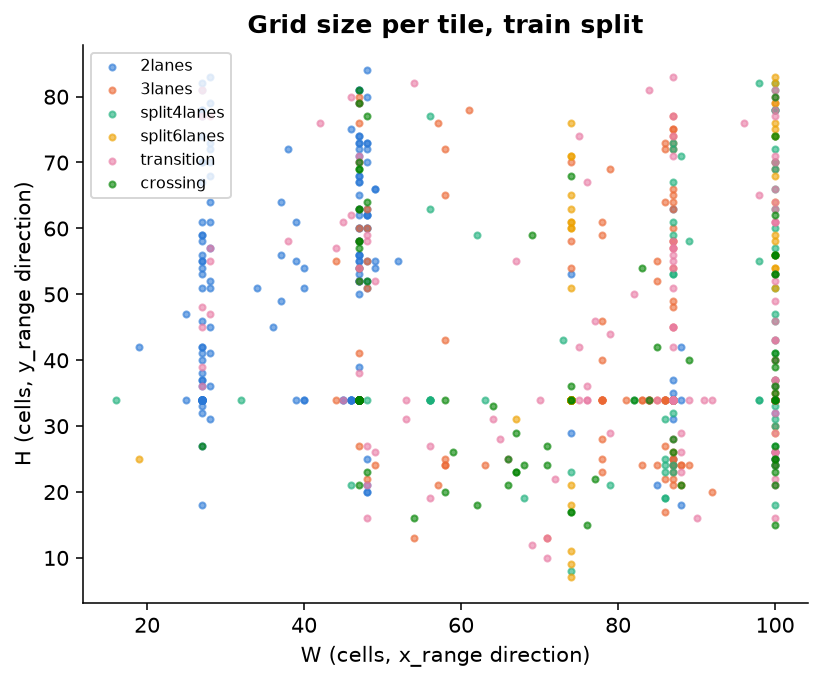

In [5]:
grid_shapes = []
for rel_path, cls, _label in train:
    pts = load_points(rel_path)
    h = int(np.floor((pts[:,1].max() - pts[:,1].min()) / RESOLUTION_M)) + 1
    w = int(np.floor((pts[:,0].max() - pts[:,0].min()) / RESOLUTION_M)) + 1
    grid_shapes.append((h, w, cls))

shape_df = pd.DataFrame(grid_shapes, columns=["H", "W", "class"])
shape_df["area"] = shape_df["H"] * shape_df["W"]
max_h, max_w = shape_df["H"].max(), shape_df["W"].max()
shape_df["fixed_window_fill"] = shape_df["area"] / (max_h * max_w)

print(f"grid H: min={shape_df['H'].min()} median={shape_df['H'].median():.0f} max={max_h}")
print(f"grid W: min={shape_df['W'].min()} median={shape_df['W'].median():.0f} max={max_w}")
print(f"if every tile were padded to the max ({max_h}x{max_w} cells), the median tile would "
      f"only fill {shape_df['fixed_window_fill'].median()*100:.0f}% of it")

fig, ax = plt.subplots(figsize=(6, 5))
for c in CLASSES:
    sub = shape_df[shape_df["class"] == c]
    ax.scatter(sub["W"], sub["H"], s=10, alpha=0.6, color=CLASS_COLORS[c], label=c)
ax.set_xlabel("W (cells, x_range direction)"); ax.set_ylabel("H (cells, y_range direction)")
ax.set_title("Grid size per tile, train split")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 2. CNN architecture

`src/cnn.py`'s `LaneCNN`: 3 conv blocks (Conv -> BatchNorm -> ReLU -> 2x2 max-pool, channels
16 -> 32 -> 64) followed by one more conv (-> 128), then global adaptive average pooling and
a linear classifier to 6 classes. `ceil_mode=True` on every pool keeps a spatial dimension of
1 from collapsing to 0, since the smallest real grid is only ~7 cells tall.

In [6]:
model = LaneCNN(in_channels=3, n_classes=len(CLASSES))
model.eval()
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\ntotal parameters: {n_params:,} (a from-scratch ResNet-18 would be ~11,200,000 -- "
      f"~{11_200_000 // n_params}x more, on ~1140 training tiles)")

LaneCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
    )
    (1): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
    )
    (2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
    )
   

**Stress-test:** forward pass on the smallest and largest real grids in the train split,
confirming the architecture handles the full range of tile sizes measured in section 1
without cropping, padding, or resizing to a fixed shape.

In [7]:
extremes = {
    "smallest H (min y_range)": shape_df.loc[shape_df["H"].idxmin()],
    "smallest W (min x_range)": shape_df.loc[shape_df["W"].idxmin()],
    "largest H (max y_range)":  shape_df.loc[shape_df["H"].idxmax()],
    "largest W (max x_range)":  shape_df.loc[shape_df["W"].idxmax()],
}

rows = []
with torch.no_grad():
    for label, row in extremes.items():
        idx = shape_df.index.get_loc(row.name)
        rel_path, cls, _ = train[idx]
        pts = load_points(rel_path)
        grid = points_to_bev(pts)
        x = torch.from_numpy(grid).unsqueeze(0)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        rows.append({
            "case": label, "class": cls, "grid (H,W)": tuple(grid.shape[1:]),
            "output shape": tuple(logits.shape), "max softmax prob": probs.max().item(),
        })
pd.DataFrame(rows)

,case,class,"grid (H,W)",output shape,max softmax prob
0,smallest H (min y_range),split6lanes,"(7, 74)","(1, 6)",0.177847
1,smallest W (min x_range),split4lanes,"(34, 16)","(1, 6)",0.175756
2,largest H (max y_range),2lanes,"(84, 48)","(1, 6)",0.176074
3,largest W (max x_range),split6lanes,"(34, 100)","(1, 6)",0.176065


Every case produces a `(1, 6)` output with no shape errors. The max softmax probability
sitting close to `1/6 ≈ 0.167` for an untrained network is the expected sanity check: the
model hasn't learned anything yet, so it shouldn't already be confident about any one class --
a strong bias here would suggest a bug in initialisation, not a real prediction.

## Next steps (remaining M3 sub-goal + M4)

Architecture is defined and verified end-to-end on real data; training is next:

- **Loss:** `nn.CrossEntropyLoss`, likely with per-class weights (same imbalance rationale as
  `class_weight="balanced"` in `src/baseline.py`).
- **Batching:** grids vary in H, W per tile (section 1), so a batch needs either a custom
  `collate_fn` that pads every grid in a batch up to that batch's own max H, W, or
  `batch_size=1`. Padding per-batch (not per-dataset) keeps the median tile from being diluted
  the way a global fixed window would.
- **Optimizer / epochs / val-loss monitoring:** per `ROADMAP.md` M3, using the frozen
  train/val split from `src/data.get_splits()` -- test stays untouched until M5.
- **Comparison:** once trained, evaluate with `src/metrics.py` (unchanged from M2) directly
  against the `random_forest` baseline numbers in `notebooks/03_baseline.ipynb` /
  `notebooks/00_project_summary.ipynb`.
- `RESOLUTION_M` (`src/bev.py`) is exposed specifically so M4 can grid-search it per
  `ROADMAP.md`.